In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df=pd.read_csv("disease_prediction_nonlinear_svm.csv")
df.head()

,Age,Blood_Sugar,Disease
0,40,108,Yes
1,23,88,No
2,26,163,No
3,52,124,Yes
4,47,177,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          200 non-null    int64 
 1   Blood_Sugar  200 non-null    int64 
 2   Disease      200 non-null    object
dtypes: int64(2), object(1)
memory usage: 4.8+ KB


In [5]:
df.shape

(200, 3)

In [6]:
df.describe()

,Age,Blood_Sugar
count,200.000000,200.000000
mean,43.905000,147.635000
std,15.614578,42.565725
min,20.000000,70.000000
25%,28.750000,109.000000
50%,43.000000,146.500000
75%,57.000000,184.250000
max,70.000000,220.000000


In [7]:
df["Disease"]=df["Disease"].map({"Yes":1,"No":0})
df.head()

,Age,Blood_Sugar,Disease
0,40,108,1
1,23,88,0
2,26,163,0
3,52,124,1
4,47,177,1


In [8]:
X=df[["Age","Blood_Sugar"]]
y=df["Disease"]

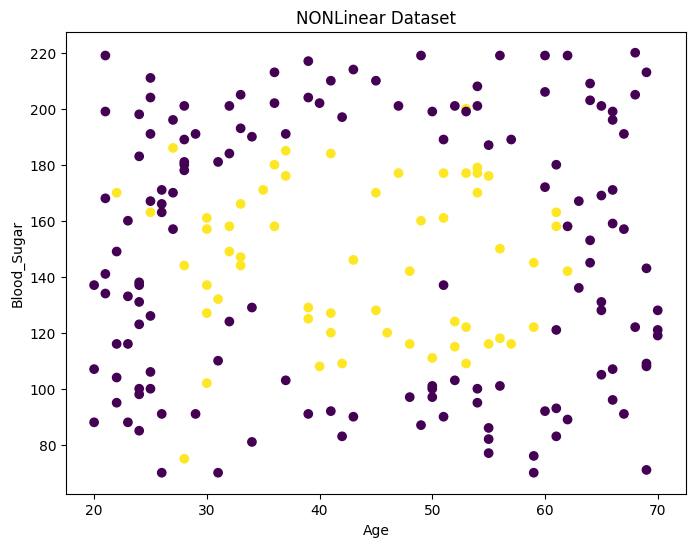

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df["Age"],df["Blood_Sugar"],c=y)
plt.xlabel("Age")
plt.ylabel("Blood_Sugar")
plt.title("NONLinear Dataset")
plt.show()

In [10]:
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:

model = SVC(kernel="rbf", gamma=0.1,random_state=42)


model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0]


In [13]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9


In [14]:
cm=confusion_matrix(y_test,y_pred)
cm=pd.DataFrame(cm)
cm


,0,1
0,30,0
1,4,6


In [15]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.94        30
           1       1.00      0.60      0.75        10

    accuracy                           0.90        40
   macro avg       0.94      0.80      0.84        40
weighted avg       0.91      0.90      0.89        40



In [16]:
new_Pa=pd.DataFrame({"Age":[40],"Blood_Sugar":[108]})

In [17]:
prediction=model.predict(new_Pa)
if prediction[0]==1:
    print("Yes")
else:
    print("No")

Yes


Text(0.5, 1.0, 'NoNLinear SVM Decision Boundary')

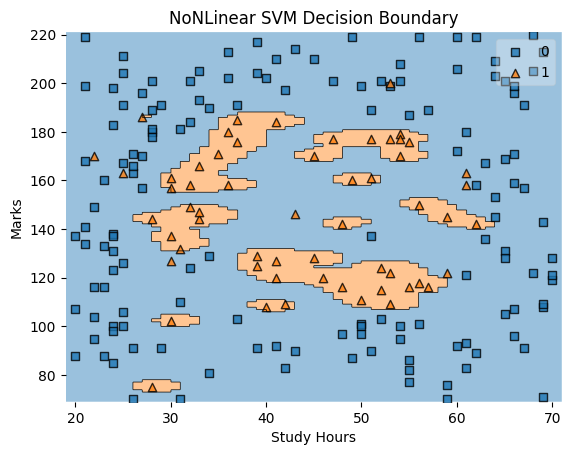

In [18]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
X_plot=X.values
y_plot=y.values
plot_decision_regions(X_plot,y_plot, clf=model)
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("NoNLinear SVM Decision Boundary")
